In [ ]:
from sklearn.metrics import pairwise_distances
from pycirclize import Circos
import numpy as np
import pandas as pd
import pickle

In [2]:
# Load tRNAs PocketVec descriptors
fps_tRNAs = pickle.load(open("../processed/pocketvec_RUN/fps_rank.pkl", 'rb'))
print(len(fps_tRNAs))

# Get outliers
outliers = {i: len(np.where(fps_tRNAs[i] > 128)[0]) for i in sorted(fps_tRNAs)}

# Remove outliers
for st in sorted(fps_tRNAs):
    if outliers[st] > 80:
        del fps_tRNAs[st]
print(len(fps_tRNAs))

# Get the protein for each PocketVec descriptor
proteins =set([i.split("_")[1] for i in sorted(fps_tRNAs)])
protein_to_index = {i:c for c,i in enumerate(proteins)}

# For each protein, get list of pockets
protein_to_pockets = {}
for p in sorted(proteins):
    protein_to_pockets[p] = [i for i in fps_tRNAs if i.split("_")[1] == p]

276
264


In [3]:
def get_min_pocketvec_distance(fps1, fps2):
    """
    Get the minimum distance between two PocketVec descriptors
    """
    return np.min(pairwise_distances(fps1, fps2, metric='cosine').flatten())   


def get_min_pocketvec_distance_same_protein(fps1, fps2):
    """
    Get the minimum distance between two PocketVec descriptors,
    using only the upper triangle of the distance matrix.
    """
    dists = pairwise_distances(fps1, fps2, metric='cosine')
    triu_indices = np.triu_indices_from(dists, k=1)
    return np.min(dists[triu_indices])  

In [4]:
POCKETVEC_DISTANCES = {}

for c1, p1 in enumerate(sorted(proteins)):
    for c2, p2 in enumerate(sorted(proteins)[c1:]):
            
            # Get the PocketVec descriptors
            fps1 = np.array([fps_tRNAs[i] for i in protein_to_pockets[p1]])
            fps2 = np.array([fps_tRNAs[i] for i in protein_to_pockets[p2]])
            
            if p1 != p2:

                # Get the minimum distance
                min_distance = get_min_pocketvec_distance(fps1, fps2)
                min_distance = round(min_distance, 3)

            else:

                # Get the minimum distance
                min_distance = get_min_pocketvec_distance_same_protein(fps1, fps2)
                min_distance = round(min_distance, 3)

            # print(f"Distance between {p1} and {p2}: {min_distance}")
            POCKETVEC_DISTANCES[(p1, p2)] = min_distance
            POCKETVEC_DISTANCES[(p2, p1)] = min_distance

In [5]:
# Mapping Uniprot AC to Gene Name
uniprot_to_gene = pd.read_csv("../data/mtb_trna_synthetases_bosch_2021_fig5.csv")
uniprot_to_gene = {i: j for i,j in zip(uniprot_to_gene['uniprot_ac'], uniprot_to_gene['gene_name_in_bosch_2021'])}

In [8]:
cmap_dict = {
    'argS':  '#50285A',   # your colors
    'alaS':  '#FAD782',
    'aspS':  '#FAA08B',
    'gatA':  '#DC9FDC',
    'gatB':  '#AA96FA',
    'thrS':  '#8DC7FA',
    'ileS':  '#BEE6B4',
    'valS':  '#D2D2D2',

    'leuS':  '#F26B38',   # added complementary colors
    'gltS':  '#4D9DE0',
    'proS':  '#6CC551',
    'glyS':  '#FFC857',
    'serS':  '#E76F51',
    'cysS1': '#2A9D8F',
    'metS':  '#F4A259',
    'lysS':  '#8A5082',
    'hisS':  '#247BA0',
    'trpS':  '#70C1B3',
    'pheS':  '#F25F5C',
    'pheT':  '#FFE066',
    'tyrS':  '#1B9C85'
}

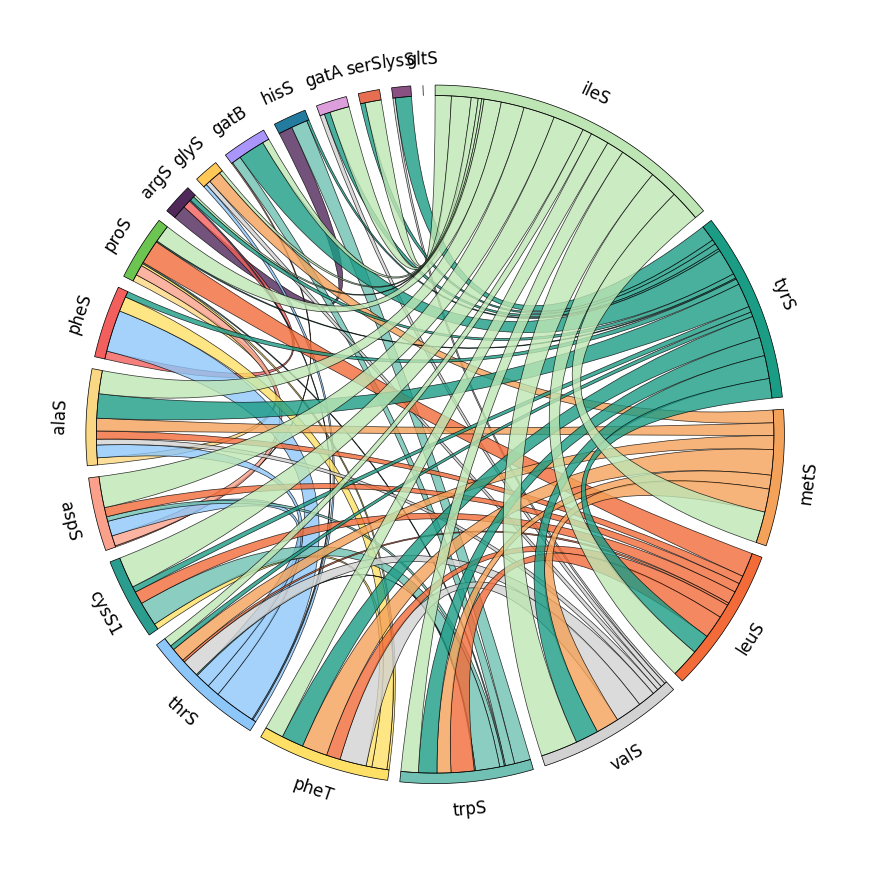

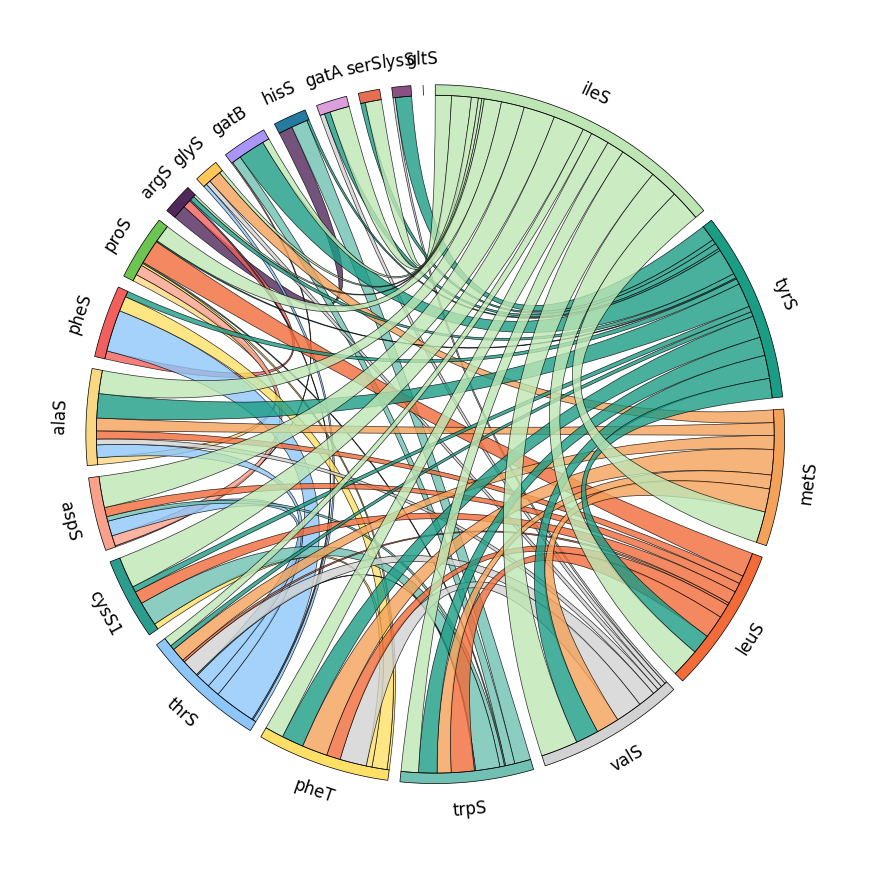

In [10]:
row_names = sorted(proteins)
matrix = [[POCKETVEC_DISTANCES[(i, j)] for j in row_names] for i in row_names]
matrix_df = pd.DataFrame(matrix, index=row_names, columns=row_names)
cut = 0.15
matrix_df = matrix_df.map(lambda x: cut - x if x < cut else 0)
np.fill_diagonal(matrix_df.values, 0)
node_strength = matrix_df.sum(axis=0) + matrix_df.sum(axis=1)
order = node_strength.sort_values(ascending=False).index
matrix_df = matrix_df.loc[order, order]
matrix_df.values[np.tril_indices_from(matrix_df, k=1)] = 0
matrix_df = matrix_df.rename(index=uniprot_to_gene).rename(columns=uniprot_to_gene)

# Create Circos chord diagram
circos = Circos.chord_diagram(
    matrix_df,
    space=2,
    cmap=cmap_dict,
    label_kws=dict(size=12),
    link_kws=dict(ec="k", lw=0.5, alpha=0.8),
)

circos.plotfig()

In [11]:
### HIT OVERLAP DL HLL-100

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as ss
import pickle
import os
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import distance
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from rdkit.Chem import Draw

plt.rcParams['figure.dpi'] = 300

In [13]:
# Define some paths
root = '.'
PATH_TO_DOCKING_RESULTS = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')

DOCKING_RESULTS = {}
DOCKING_RESULTS_SORTED = {}
# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS))):
        # Get scores
        scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS, pocket, 'report.csv'))
        # Save results
        scores = {i: j for i, j in zip(scores['compound'], scores['score'])}
        DOCKING_RESULTS[pocket] = scores
        DOCKING_RESULTS_SORTED[pocket] = sorted(scores, key = lambda x: scores[x])

100%|██████████| 276/276 [00:13<00:00, 20.74it/s]


In [15]:
# Get proteins
proteins = sorted(set([i.split("_")[1] for i in DOCKING_RESULTS]))

# Get proteins to pockets
proteins_to_pockets = {i: set([j for j in DOCKING_RESULTS if j.split("_")[1] == i]) for i in proteins}

# Get proteins to hits
proteins_to_hits_10 = {i: set() for i in proteins}
proteins_to_hits_100 = {i: set() for i in proteins}
proteins_to_hits_1_000 = {i: set() for i in proteins}
proteins_to_hits_10_000 = {i: set() for i in proteins}
for pocket in sorted(DOCKING_RESULTS_SORTED):
    proteins_to_hits_10[pocket.split("_")[1]].update(DOCKING_RESULTS_SORTED[pocket][:10])
    proteins_to_hits_100[pocket.split("_")[1]].update(DOCKING_RESULTS_SORTED[pocket][:100])
    proteins_to_hits_1_000[pocket.split("_")[1]].update(DOCKING_RESULTS_SORTED[pocket][:1_000])
    proteins_to_hits_10_000[pocket.split("_")[1]].update(DOCKING_RESULTS_SORTED[pocket][:10_000])

# Mapping Uniprot AC to Gene Name
uniprot_to_gene = pd.read_csv("../data/mtb_trna_synthetases_bosch_2021_fig5.csv")
uniprot_to_gene = {i: j for i,j in zip(uniprot_to_gene['uniprot_ac'], uniprot_to_gene['gene_name_in_bosch_2021'])}

cols = ["Uniprot AC", "Gene name", "Number of pocket structures", "Number of hits (TOP-10)",
        "Number of hits (TOP-100)", "Number of hits (TOP-1000)", "Number of hits (TOP-10000)"]
df = []

# For each protein
for protein in sorted(protein_to_pockets):

    # Get data
    gene = uniprot_to_gene[protein]
    pckts = str(len(protein_to_pockets[protein]))
    hits_10 = str(len(proteins_to_hits_10[protein]))
    hits_100 = str(len(proteins_to_hits_100[protein]))
    hits_1000 = str(len(proteins_to_hits_1_000[protein]))
    hits_10000 = str(len(proteins_to_hits_10_000[protein]))
    df.append([protein, gene, pckts, hits_10, hits_100, hits_1000, hits_10000])

df = pd.DataFrame(df, columns=cols)
df.to_csv(os.path.join(root, "..", "processed", "unidock_docking", 'hit_overview.csv'), index=False)

In [24]:
def get_hit_overlap_norm(h1, h2):
    return len(h1.intersection(h2)) / min(len(h1), len(h2))

def get_hit_overlap(h1, h2):
    return len(h1.intersection(h2))

In [31]:
HIT_OVERLAP_10 = {}
HIT_OVERLAP_100 = {}
HIT_OVERLAP_1_000 = {}
HIT_OVERLAP_10_000 = {}

for c1, p1 in enumerate(sorted(proteins)):
    for c2, p2 in enumerate(sorted(proteins)[c1:]):
            
            # HIT_OVERLAP_10[(p1, p2)] = get_hit_overlap_norm(proteins_to_hits_10[p1], proteins_to_hits_10[p2])
            # HIT_OVERLAP_100[(p1, p2)] = get_hit_overlap_norm(proteins_to_hits_100[p1], proteins_to_hits_100[p2])
            # HIT_OVERLAP_1_000[(p1, p2)] = get_hit_overlap_norm(proteins_to_hits_1_000[p1], proteins_to_hits_1_000[p2])
            # HIT_OVERLAP_10_000[(p1, p2)] = get_hit_overlap_norm(proteins_to_hits_10_000[p1], proteins_to_hits_10_000[p2])

            HIT_OVERLAP_10[(p1, p2)] = get_hit_overlap(proteins_to_hits_10[p1], proteins_to_hits_10[p2])
            HIT_OVERLAP_100[(p1, p2)] = get_hit_overlap(proteins_to_hits_100[p1], proteins_to_hits_100[p2])
            HIT_OVERLAP_1_000[(p1, p2)] = get_hit_overlap(proteins_to_hits_1_000[p1], proteins_to_hits_1_000[p2])
            HIT_OVERLAP_10_000[(p1, p2)] = get_hit_overlap(proteins_to_hits_10_000[p1], proteins_to_hits_10_000[p2])

            HIT_OVERLAP_10[(p2, p1)] = HIT_OVERLAP_10[(p1, p2)]
            HIT_OVERLAP_100[(p2, p1)] = HIT_OVERLAP_100[(p1, p2)]
            HIT_OVERLAP_1_000[(p2, p1)] = HIT_OVERLAP_1_000[(p1, p2)]
            HIT_OVERLAP_10_000[(p2, p1)] = HIT_OVERLAP_10_000[(p1, p2)]

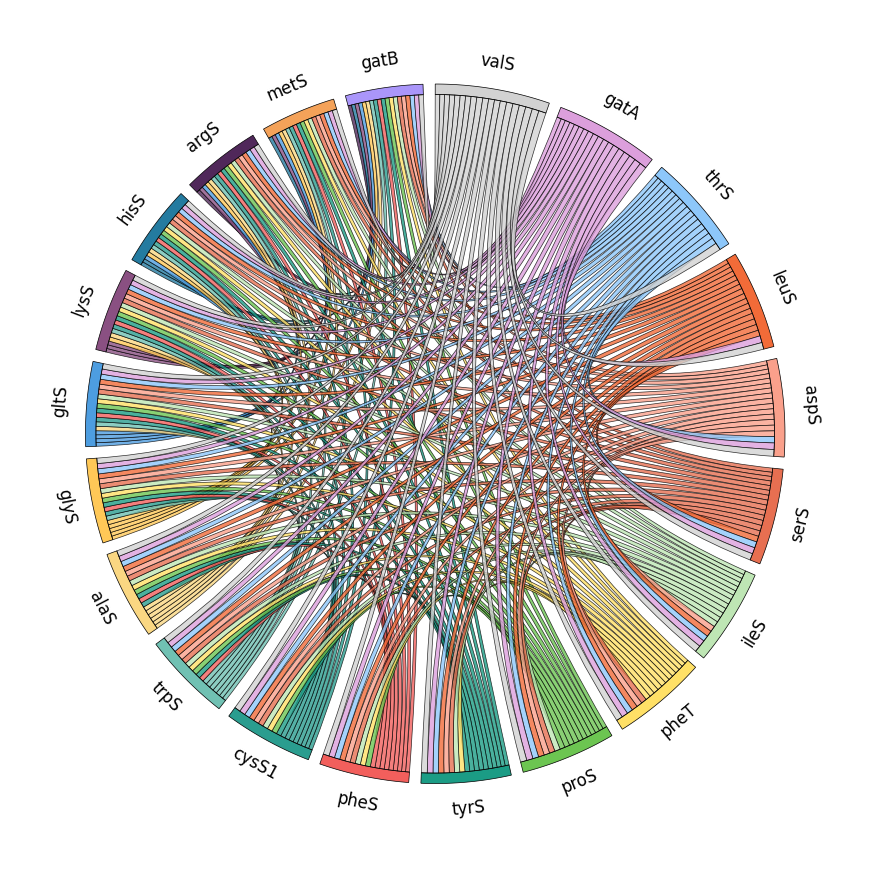

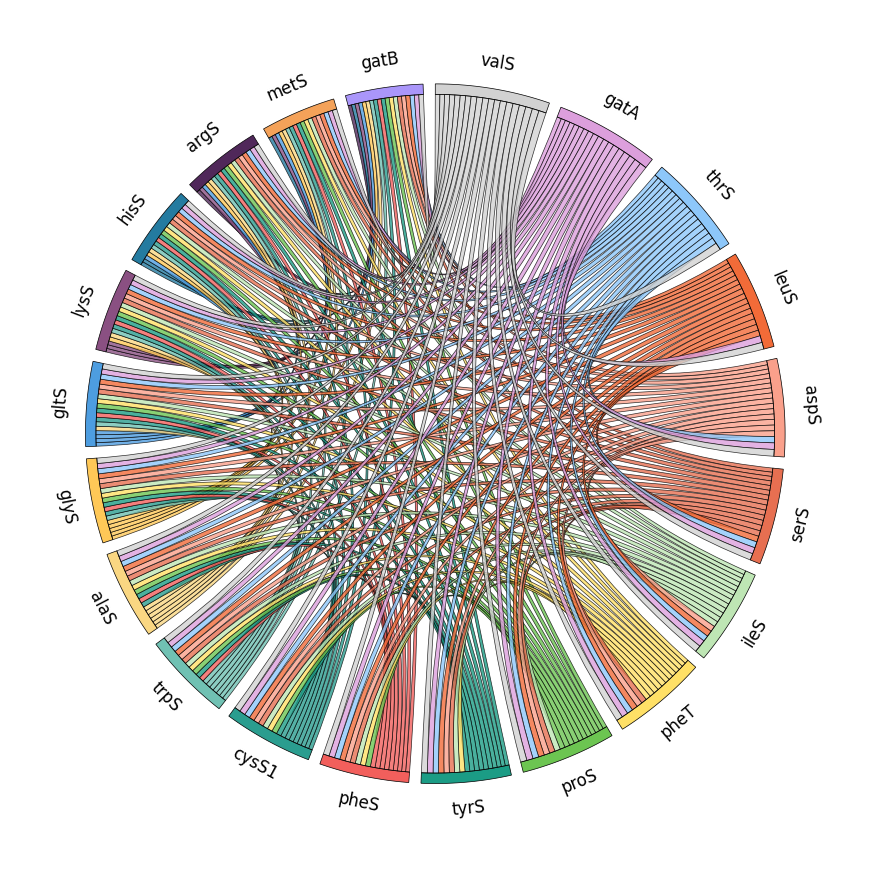

In [36]:
row_names = sorted(proteins)
matrix = [[HIT_OVERLAP_10[(i, j)] for j in row_names] for i in row_names]
matrix = [[HIT_OVERLAP_100[(i, j)] for j in row_names] for i in row_names]
matrix = [[HIT_OVERLAP_1_000[(i, j)] for j in row_names] for i in row_names]
matrix = [[HIT_OVERLAP_10_000[(i, j)] for j in row_names] for i in row_names]
matrix_df = pd.DataFrame(matrix, index=row_names, columns=row_names)
np.fill_diagonal(matrix_df.values, 0)
node_strength = matrix_df.sum(axis=0) + matrix_df.sum(axis=1)
order = node_strength.sort_values(ascending=False).index
matrix_df = matrix_df.loc[order, order]
matrix_df.values[np.tril_indices_from(matrix_df, k=1)] = 0
matrix_df = matrix_df.rename(index=uniprot_to_gene).rename(columns=uniprot_to_gene)

# Create Circos chord diagram
circos = Circos.chord_diagram(
    matrix_df,
    space=2,
    cmap=cmap_dict,
    label_kws=dict(size=12),
    link_kws=dict(ec="k", lw=0.5, alpha=0.8),
)

circos.plotfig()